# **Particiones en árboles de clasificación**

**Conjunto de datos de Celebrity Popularity Insights**

Diana Fernanda Barbosa Dueñas

756920

Ingeniería Financiera

GINI

R: ”Métrica utilizada principalmente en los árboles de decisión (algoritmos como CART - Classification and Regression Trees) para medir la "impureza" o mezcla de clases en un nodo.”(Tamas Ujhelyi)
Conforme las clases se mezclan más, el valor aumenta. En los árboles de clasificación se utiliza para encontrar divisiones que separen mejor las categorías y generen grupos más homogéneos.

Entropía

R: La entropía mide el nivel de desorden o incertidumbre que existe en un nodo. Cuando todas las muestras pertenecen a la misma clase, la entropía es baja porque no hay duda sobre la clasificación. En cambio, cuando las clases están muy mezcladas, la entropía aumenta. Los árboles usan este criterio para elegir la partición que reduce más la incertidumbre y facilita distinguir las categorías.

Log Loss

R: El Log Loss evalúa qué tan buenas son las probabilidades predichas por el modelo. No solamente considera si la predicción fue correcta o incorrecta, sino también qué tan seguro estaba el modelo de esa decisión. Penaliza más los errores cuando el modelo estaba muy confiado y se equivocó. En árboles de clasificación modernos puede utilizarse como criterio para mejorar la calidad de las probabilidades generadas.

¿Cuál es la diferencia entre entropía y log loss?

R: La entropía y el log loss están relacionados matemáticamente, pero se usan de forma diferente. La entropía se enfoca en medir la impureza o incertidumbre dentro de un nodo del árbol para decidir cómo dividir los datos.

En cambio, el log loss mide el desempeño de las probabilidades predichas por el modelo completo. En otras palabras, la entropía ayuda a construir el árbol y el log loss ayuda a evaluar qué tan buenas son sus predicciones probabilísticas.


In [ ]:
from google.colab import files
upload = files.upload()

Saving popular_people.csv to popular_people.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Datos**

In [ ]:
celeb = pd.read_csv('popular_people.csv')
celeb.head()

,name,gender,known_for_department,original_name,popularity
0,Eric Larson,2,Visual Effects,Eric Larson,47.9780
1,Robert Middlemass,2,Acting,Robert Middlemass,47.8017
2,María Vaner,1,Acting,María Vaner,47.2016
3,Carl Wharton,2,Acting,Carl Wharton,36.3365
4,Victor Moore,2,Acting,Victor Moore,35.9181


In [ ]:
celeb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9980 entries, 0 to 9979
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  9980 non-null   object 
 1   gender                9980 non-null   int64  
 2   known_for_department  9975 non-null   object 
 3   original_name         9980 non-null   object 
 4   popularity            9980 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 390.0+ KB


**Variables**

In [ ]:
celeb['Popular'] = np.where(celeb['popularity'] >= celeb['popularity'].median(), 1, 0)

**Varibles predictoras**

In [ ]:
X = celeb[['gender', 'known_for_department', 'popularity']]
y = celeb['Popular']

In [ ]:
X = pd.get_dummies(X)
X.head()

,gender,popularity,known_for_department_Acting,known_for_department_Art,known_for_department_Camera,known_for_department_Costume & Make-Up,known_for_department_Creator,known_for_department_Crew,known_for_department_Directing,known_for_department_Editing,known_for_department_Lighting,known_for_department_Production,known_for_department_Sound,known_for_department_Visual Effects,known_for_department_Writing
0,2,47.9780,False,False,False,False,False,False,False,False,False,False,False,True,False
1,2,47.8017,True,False,False,False,False,False,False,False,False,False,False,False,False
2,1,47.2016,True,False,False,False,False,False,False,False,False,False,False,False,False
3,2,36.3365,True,False,False,False,False,False,False,False,False,False,False,False,False
4,2,35.9181,True,False,False,False,False,False,False,False,False,False,False,False,False


**Train-test**

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

**Árbol usando GINI**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
modelo_gini = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=42
)

In [ ]:
modelo_gini.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

**Accuracy GINI**

In [ ]:
accuracy_gini = modelo_gini.score(X_test, y_test)

In [ ]:
print('Accuracy GINI:', accuracy_gini)

Accuracy GINI: 0.9993319973279893


**Árbol usando Entropía**

In [ ]:
modelo_entropy = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    random_state=42
)

In [ ]:
modelo_entropy.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

**Accuracy Entropía**

In [ ]:
accuracy_entropy = modelo_entropy.score(X_test, y_test)

In [ ]:
print('Accuracy Entropía:', accuracy_entropy)

Accuracy Entropía: 0.9993319973279893


**Árbol Log Loss**

In [ ]:
modelo_logloss = DecisionTreeClassifier(
    criterion='log_loss',
    max_depth=3,
    random_state=42
)

In [ ]:
modelo_logloss.fit(X_train, y_train)

DecisionTreeClassifier(criterion='log_loss', max_depth=3, random_state=42)

**Accuracy Log Loss**

In [ ]:
accuracy_logloss = modelo_logloss.score(X_test, y_test)

In [ ]:
print('Accuracy Log Loss:', accuracy_logloss)

Accuracy Log Loss: 0.9993319973279893


**Comparación de resultados**

In [ ]:
print('GINI:', accuracy_gini)
print('ENTROPÍA:', accuracy_entropy)
print('LOG LOSS:', accuracy_logloss)

GINI: 0.9993319973279893
ENTROPÍA: 0.9993319973279893
LOG LOSS: 0.9993319973279893


**Visualización de Árbol en GINI**

In [ ]:
import matplotlib.pyplot as plt
from sklearn import tree

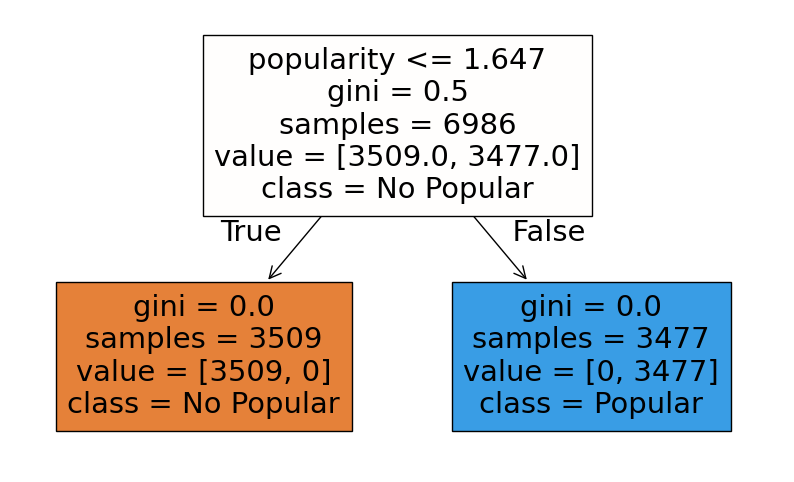

In [ ]:
plt.figure(figsize=(10,6))

tree.plot_tree(
    modelo_gini,
    feature_names=X.columns,
    class_names=['No Popular','Popular'],
    filled=True
)

plt.show()

**Visualización de Árbol en Entropía**

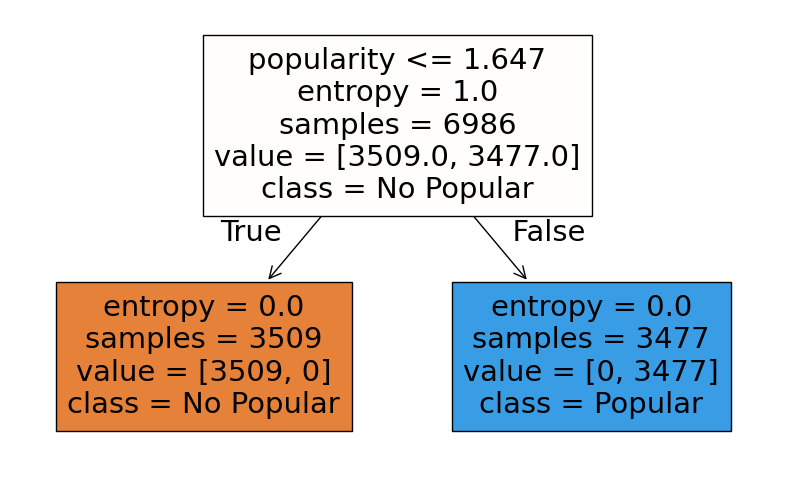

In [ ]:
plt.figure(figsize=(10,6))

tree.plot_tree(
    modelo_entropy,
    feature_names=X.columns,
    class_names=['No Popular','Popular'],
    filled=True
)

plt.show()

**Visualización de Árbol en Log Loss**

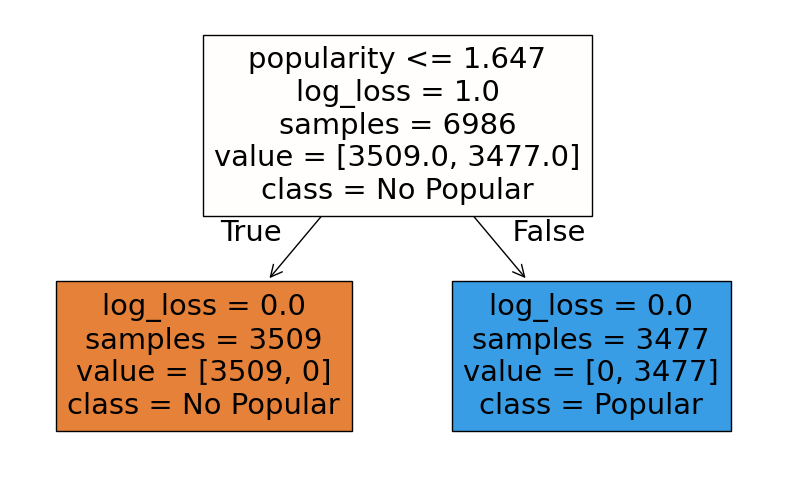

In [ ]:
plt.figure(figsize=(10,6))

tree.plot_tree(
    modelo_logloss,
    feature_names=X.columns,
    class_names=['No Popular','Popular'],
    filled=True
)

plt.show()

**Conclusiones**

Después de agregar más variables predictoras al modelo, el desempeño del árbol de clasificación mejoró porque ahora el algoritmo tiene más información para identificar patrones relacionados con la popularidad de las celebridades.

Variables como seguidores, interacción o edad aportan características más relevantes que solo utilizar una sola variable, por lo que las particiones realizadas por el árbol son más precisas. Esto demuestra que la calidad y cantidad de variables influyen directamente en la capacidad del modelo para clasificar correctamente los datos.

**Referencias**

IBM. “Topics.” Ibm.com, 7 Oct. 2024, www.ibm.com/think/topics.

msmk. “Logloss - MSMK.” MSMK, 12 Dec. 2024, msmk.university/logloss/.

Tamas Ujhelyi. “Coding a Decision Tree in Python (Classification Trees and Gini Impurity).” Data36, 16 Feb. 2022, data36-com.translate.goog/coding-a-decision-tree-in-python-classification-tree-gini-impurity/?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=sge.

Zubaira Maimona. “Celebrity Popularity Insights Dataset.” Kaggle.com, 2026, www.kaggle.com/datasets/itszubi/celebrity-popularity-insights-dataset.